# 🤖 Pipeline de pré-processamento e modelagem

Este notebook treina e compara os modelos que preveem se um aluno será alfabetizado. Ele parte da tabela analítica do [desenv_01](desenv_01_base_analitica.ipynb) e da lista de variáveis decidida na análise exploratória do [desenv_02](desenv_02_analise_exploratoria.ipynb), gravada em `reports/variaveis_modelagem.csv`.

> **Convenção de trabalho:** o desenvolvimento acontece neste notebook, célula a célula, com os resultados salvos. Ao final da etapa, o código estável é promovido para `src/modeling/prod_03_pipeline_modelagem.py`.

**Decisões que governam este notebook** (ver [diário de decisões](../docs/decisoes.md)):
- **D-001, grão de modelagem:** a predição é feita para cada aluno;
- **D-010, conjunto de variáveis:** 43 variáveis explicativas, com 4 indicadores de ausência;
- **D-011, tratamento das variáveis:** imputação pela mediana da UF, codificação one-hot, logaritmo e padronização só em modelo linear, rede privada fora.

---

## Roteiro

| Seção | Etapa | O que responde |
|---|---|---|
| 1 | Dados | carregar a base, aplicar a lista de variáveis e preparar as partições |
| 2 | Pré-processamento | imputação, indicadores de ausência, codificação e transformação, dentro do pipeline |
| 3 | Referências | quanto acerta um modelo ingênuo e uma regressão logística |
| 4 | Ganho por bloco de hipótese | quanto cada hipótese acrescenta ao desempenho anterior (H8) |
| 5 | Modelos candidatos e hiperparâmetros | regressão logística, XGBoost e Random Forest, com busca aleatória de hiperparâmetros |
| 6 | Comparação na validação | qual modelo segue para a avaliação final |

O notebook termina com um **parecer final** sobre o que o modelo entrega e como ele será usado nas etapas seguintes.

**Como os modelos são comparados.** Nas seções 3 a 5, a comparação usa validação cruzada em cinco partes dentro da partição de treino, **agrupada por município**: todos os alunos de um município ficam na mesma parte, pelo mesmo motivo da partição do desenv_01. A partição de validação é usada só na seção 6, para confirmar a escolha entre os finalistas. A partição de teste não é aberta neste notebook: ela fica para a avaliação final, no desenv_04.

**O que o modelo entrega.** Para cada aluno, a probabilidade de ser alfabetizado; com um limiar, essa probabilidade vira a classe, alfabetizado ou não. Como o corte de 743 pontos cai sobre a região mais densa das notas (seção 2.2 do desenv_02), a qualidade do modelo é medida pela probabilidade, com AUC e log-loss, e não pela acurácia.

## 1. Dados

**Passos desta seção:** (1.1) configurar o acesso ao data lake; (1.2) carregar a base e aplicar a lista de variáveis; (1.3) agrupar os alunos que têm as mesmas variáveis.

In [6]:
# --- 1.1 Configuração e acesso ao data lake ---
import io
import json
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydata_google_auth
from google.cloud import storage

warnings.filterwarnings("ignore")
# os processos auxiliares do joblib não herdam o filtro acima; a variável
# de ambiente vale também para eles
os.environ["PYTHONWARNINGS"] = "ignore"
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

CFG = json.loads(Path("../config/config.json").read_text(encoding="utf-8"))
PROJETO_GCP = CFG["projeto_gcp"]
BUCKET_LAKE = CFG["bucket_lake"]

ESCOPOS = ["https://www.googleapis.com/auth/cloud-platform"]
credenciais = pydata_google_auth.get_user_credentials(ESCOPOS)
credenciais = credenciais.with_quota_project(PROJETO_GCP)
cliente_storage = storage.Client(project=PROJETO_GCP, credentials=credenciais)


def ler_lake(area: str, tabela: str) -> pd.DataFrame:
    """Lê a partição mais recente de uma tabela do lake, a partir da memória."""
    particoes = sorted({
        b.name.split("/")[2]
        for b in cliente_storage.list_blobs(BUCKET_LAKE, prefix=f"{area}/{tabela}/")
        if len(b.name.split("/")) > 2
    })
    if not particoes:
        raise FileNotFoundError(
            f"Tabela '{tabela}' não encontrada em {area}/. "
            "Execute antes o notebook desenv_01_base_analitica.")
    caminho = f"{area}/{tabela}/{particoes[-1]}/{tabela}.parquet"
    blob = cliente_storage.bucket(BUCKET_LAKE).blob(caminho)
    print(f"  lendo {caminho}")
    return pd.read_parquet(io.BytesIO(blob.download_as_bytes()))


print(f"Lake: gs://{BUCKET_LAKE}/")
print("Setup ok")

Lake: gs://tech-challenge-fase2-lake-rm373453/
Setup ok


### 1.2 Carregar a base e aplicar a lista de variáveis

A lista da análise exploratória diz quais variáveis entram e como cada uma é tratada. Uma trava confere que todas estão na base. Os 24 alunos da rede privada saem aqui, conforme a D-011.

In [7]:
# --- 1.2 Carregar a base e a lista de variáveis ---
abt = ler_lake("ml", "abt_alfabetizacao")
lista = pd.read_csv("../reports/variaveis_modelagem.csv", index_col="variavel")

entram = lista[lista["situacao"] == "entra"]
CATEGORICAS = entram.index[entram["tipo"] == "categórica"].tolist()
NUMERICAS = entram.index[entram["tipo"] == "numérica"].tolist()
VARIAVEIS = NUMERICAS + CATEGORICAS

# Trava: toda variável da lista precisa estar na base
faltam = [v for v in VARIAVEIS if v not in abt.columns]
if faltam:
    raise RuntimeError(f"Variáveis da lista ausentes na base: {faltam}. "
                       "Reexecute o desenv_01 e a seção 12 do desenv_02.")

# A rede privada fica fora da modelagem (D-011)
privada = abt["rede_nome"] == "Privada"
abt = abt.loc[~privada, ["particao", "id_municipio", "alvo"] + VARIAVEIS].copy()

print(f"Variáveis explicativas: {len(VARIAVEIS)} "
      f"({len(NUMERICAS)} numéricas, {len(CATEGORICAS)} categóricas)")
print(f"Alunos da rede privada retirados: {int(privada.sum())}")
print()
print(abt.groupby("particao")
      .agg(alunos=("alvo", "size"), municipios=("id_municipio", "nunique"),
           taxa=("alvo", "mean"))
      .assign(taxa=lambda d: (100 * d["taxa"]).round(1))
      .reindex(["treino", "validacao", "teste"]).to_string())

  lendo ml/abt_alfabetizacao/data_processamento=2026-09-14/abt_alfabetizacao.parquet
Variáveis explicativas: 43 (40 numéricas, 3 categóricas)
Alunos da rede privada retirados: 24

            alunos  municipios  taxa
particao                            
treino     1156013        3310  59.4
validacao   384021        1103  60.0
teste       311794        1104  60.8


### 1.3 Agrupar os alunos que têm as mesmas variáveis

🎓 **Conceito, por que agrupar não muda o modelo.** A única variável que distingue um aluno de outro é a rede; todas as demais são do município ou da rede no município. Dois alunos da mesma rede, no mesmo município, têm exatamente as mesmas variáveis, e qualquer modelo dará aos dois a mesma probabilidade. Por isso, treinar sobre os alunos equivale a treinar sobre os grupos de município e rede, desde que cada grupo pese pelo número de alunos que representa.

O agrupamento usa duas linhas por grupo: uma para os alunos alfabetizados e outra para os não alfabetizados, cada uma com peso igual ao número de alunos daquela classe. A função de perda dos modelos, a log-loss, soma o erro de cada aluno; com os pesos, ela soma exatamente os mesmos termos, só que em poucas linhas. O resultado é o mesmo modelo, com cada rodada de treino muito mais rápida.

⚠️ **O que o agrupamento torna visível:** o número efetivo de observações distintas não é 1,1 milhão de alunos, e sim alguns milhares de combinações de município e rede. Modelos muito complexos podem decorar essas combinações; a validação agrupada por município é a defesa contra isso.

A trava abaixo confere que as variáveis são de fato idênticas dentro de cada grupo antes de agrupar.

In [8]:
# --- 1.3 Agrupar os alunos que têm as mesmas variáveis ---
CHAVE = ["particao", "id_municipio", "rede_nome"]

# Trava: dentro de cada grupo, nenhuma variável pode variar entre os alunos
variacao = (abt.groupby(CHAVE, observed=True)[NUMERICAS + ["sigla_uf", "nome_regiao"]]
            .nunique(dropna=False).max())
variam = variacao[variacao > 1]
if len(variam):
    raise RuntimeError(f"Variáveis que variam dentro do grupo: {variam.to_dict()}")

grupos = (abt.groupby(CHAVE, observed=True)
          .agg(alunos=("alvo", "size"), alfabetizados=("alvo", "sum"),
               **{v: (v, "first") for v in NUMERICAS + ["sigla_uf", "nome_regiao"]})
          .reset_index())

# Duas linhas por grupo, uma por classe, cada uma pesando pelos seus alunos
sim = grupos.assign(alvo=1, peso=grupos["alfabetizados"])
nao = grupos.assign(alvo=0, peso=grupos["alunos"] - grupos["alfabetizados"])
dados = (pd.concat([sim, nao], ignore_index=True)
         .query("peso > 0")
         .drop(columns=["alunos", "alfabetizados"])
         .reset_index(drop=True))

# Trava: o agrupamento preserva o número de alunos e a taxa de cada partição
conferencia = pd.DataFrame({
    "alunos": abt.groupby("particao").size(),
    "alunos_agrupados": dados.groupby("particao")["peso"].sum(),
    "taxa": abt.groupby("particao")["alvo"].mean(),
    "taxa_agrupada": dados.assign(p=dados["alvo"] * dados["peso"])
                          .groupby("particao")["p"].sum() / dados.groupby("particao")["peso"].sum(),
})
if not (np.allclose(conferencia["alunos"], conferencia["alunos_agrupados"])
        and np.allclose(conferencia["taxa"], conferencia["taxa_agrupada"])):
    raise RuntimeError("O agrupamento alterou o número de alunos ou a taxa.")


def separar(particao: str):
    """Variáveis, resposta, peso e município de uma partição."""
    d = dados[dados["particao"] == particao]
    return d[VARIAVEIS], d["alvo"], d["peso"], d["id_municipio"]


X_treino, y_treino, w_treino, municipio_treino = separar("treino")
X_validacao, y_validacao, w_validacao, municipio_validacao = separar("validacao")

print("DE ALUNOS PARA GRUPOS")
print(pd.DataFrame({
    "alunos": abt.groupby("particao").size(),
    "grupos_municipio_rede": grupos.groupby("particao").size(),
    "linhas_para_o_modelo": dados.groupby("particao").size(),
}).reindex(["treino", "validacao", "teste"]).to_string())
print()
print("Conferência: número de alunos e taxa de cada partição preservados.")
print(f"Treino pronto: {len(X_treino):,} linhas, {X_treino.shape[1]} variáveis, "
      f"{municipio_treino.nunique():,} municípios")

DE ALUNOS PARA GRUPOS
            alunos  grupos_municipio_rede  linhas_para_o_modelo
particao                                                       
treino     1156013                   3893                  7736
validacao   384021                   1312                  2607
teste       311794                   1330                  2643

Conferência: número de alunos e taxa de cada partição preservados.
Treino pronto: 7,736 linhas, 43 variáveis, 3,310 municípios


## 2. Pré-processamento

**Passos desta seção:** (2.1) montar os passos de pré-processamento; (2.2) conferir o resultado sobre a partição de treino.

Os tratamentos seguem a D-011 e a lista da análise exploratória:

| Passo | O que faz | Modelo linear | Modelo de árvore |
|---|---|---|---|
| indicadores de ausência | marca com 1 os alunos sem histórico da rede, sem indicador do município, sem microdados ou sem meta | sim | sim |
| imputação | preenche cada ausente com a mediana da variável na UF do aluno; na falta dela, com a mediana nacional | sim | sim |
| logaritmo (`FunctionTransformer` com `np.log1p`) | comprime a escala das 5 variáveis de cauda longa | sim | não |
| padronização (`StandardScaler`) | subtrai a média e divide pelo desvio padrão de cada variável numérica, calculados no treino, pondo todas na mesma escala, o que a regularização da regressão logística exige | sim | não |
| one-hot | uma coluna por categoria de rede, UF e região; categoria não vista no treino recebe zero | sim | sim |

**Logaritmo e padronização não são alternativas.** A padronização, feita com o `StandardScaler` do scikit-learn, subtrai a média e divide pelo desvio padrão: iguala as escalas, mas não muda a forma da distribuição, e uma variável de cauda longa continua de cauda longa depois dela. O logaritmo muda a forma: comprime a cauda, para que poucos municípios muito grandes, ricos ou densos não pesem desproporcionalmente no coeficiente. Por isso, no modelo linear, as 5 variáveis de cauda longa passam pelos dois passos, nessa ordem, e as demais só pela padronização.

🎓 **Conceito, por que o pré-processamento fica dentro do pipeline.** A mediana usada na imputação é aprendida com os dados. Se ela fosse calculada uma vez, com a partição de treino inteira, cada rodada da validação cruzada avaliaria o modelo numa parte cujos valores já teriam influenciado a mediana: um vazamento pequeno, mas real. Dentro do pipeline, cada rodada recalcula as medianas só com as partes de treino daquela rodada, e a parte de avaliação fica intocada.

A imputação pela mediana da UF não existe pronta no scikit-learn, e por isso é implementada abaixo como um transformador próprio, com a mesma interface dos demais: aprende no `fit` e aplica no `transform`.

In [9]:
# --- 2.1 Passos de pré-processamento ---
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


class PreparadorAusencias(BaseEstimator, TransformerMixin):
    """Cria os indicadores de ausência e imputa pela mediana da UF.

    As medianas são aprendidas no fit, só com os dados de treino, e
    aplicadas no transform. A UF sem valor para uma variável recebe a
    mediana nacional.
    """

    def __init__(self, numericas: list, indicadores: dict, coluna_uf: str = "sigla_uf"):
        self.numericas = numericas
        self.indicadores = indicadores
        self.coluna_uf = coluna_uf

    def fit(self, X, y=None):
        valores = X[self.numericas].astype("float64")
        self.medianas_uf_ = valores.groupby(X[self.coluna_uf]).median()
        self.medianas_nacionais_ = valores.median()
        return self

    def transform(self, X):
        X = X.copy()
        # os indicadores vêm antes da imputação, que apaga o sinal da ausência
        for nome, variavel in self.indicadores.items():
            X[nome] = X[variavel].isna().astype("int64")
        valores = X[self.numericas].astype("float64")
        da_uf = self.medianas_uf_.reindex(X[self.coluna_uf]).set_index(X.index)
        X[self.numericas] = valores.fillna(da_uf).fillna(self.medianas_nacionais_)
        return X


# O que a lista da análise exploratória determina
INDICADORES = {nome: variavel for variavel, nome
               in entram["indicador_ausencia"].dropna().items()}
COM_LOG = entram.index[entram["transformacao"].notna()].tolist()


def montar_preprocessamento(linear: bool, variaveis: list | None = None) -> Pipeline:
    """Pré-processamento completo; linear=True acrescenta logaritmo e padronização.

    variaveis restringe o pré-processamento a um subconjunto da lista, o que a
    seção 4 usa para comparar blocos de hipótese; por padrão, usa todas.
    """
    usar = set(variaveis or VARIAVEIS)
    numericas = [v for v in NUMERICAS if v in usar]
    categoricas = [v for v in CATEGORICAS if v in usar]
    indicadores = {n: v for n, v in INDICADORES.items() if v in usar}
    com_log = [v for v in COM_LOG if v in usar]
    sem_log = [v for v in numericas if v not in com_log] + list(indicadores)
    if linear:
        passos = [("log", Pipeline([
                      ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                      ("escala", StandardScaler())]), com_log),
                  ("numericas", StandardScaler(), sem_log)]
    else:
        passos = [("numericas", "passthrough", com_log + sem_log)]
    passos.append(("categoricas",
                   OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                   categoricas))
    colunas = ColumnTransformer(passos, verbose_feature_names_out=False)
    colunas.set_output(transform="pandas")
    return Pipeline([("ausencias", PreparadorAusencias(numericas, indicadores)),
                     ("colunas", colunas)])


print(f"Indicadores de ausência: {', '.join(f'{n} ({v})' for n, v in INDICADORES.items())}")
print(f"Logaritmo, só no linear: {', '.join(COM_LOG)}")
print(f"One-hot: {', '.join(CATEGORICAS)}")

Indicadores de ausência: sem_rede_ant (rede_taxa_ant), sem_municipio_ant (rede_vs_municipio), sem_microdados_ant (mun_participacao_ant), sem_meta (mun_gap_meta)
Logaritmo, só no linear: esc_pct_area_diferenciada, mun_pib_per_capita, mun_populacao, mun_densidade_demografica, mun_pct_vulner_deslocamento_1h
One-hot: rede_nome, sigla_uf, nome_regiao


### 2.2 Conferir o resultado

A célula abaixo ajusta as duas versões do pré-processamento na partição de treino e confere o que sai delas: nenhuma célula vazia, o número de colunas e a fração de alunos marcada por cada indicador de ausência. As frações são ponderadas pelo número de alunos de cada linha, para que correspondam aos alunos, e não aos grupos.

In [10]:
# --- 2.2 Conferir o pré-processamento na partição de treino ---
preparo_linear = montar_preprocessamento(linear=True).fit(X_treino)
preparo_arvore = montar_preprocessamento(linear=False).fit(X_treino)
saida_linear = preparo_linear.transform(X_treino)
saida_arvore = preparo_arvore.transform(X_treino)

# Travas: nada vazio depois do pré-processamento, e as duas versões com as mesmas colunas
for nome, saida in [("linear", saida_linear), ("árvore", saida_arvore)]:
    vazias = int(saida.isna().sum().sum())
    if vazias:
        raise RuntimeError(f"Pré-processamento {nome} deixou {vazias} células vazias.")
if sorted(saida_linear.columns) != sorted(saida_arvore.columns):
    raise RuntimeError("As duas versões do pré-processamento geraram colunas diferentes.")

categorias = {c: int(sum(col.startswith(c + "_") for col in saida_linear.columns))
              for c in CATEGORICAS}
print("COLUNAS QUE ENTRAM NO MODELO")
print(f"  numéricas            {len(NUMERICAS):>3}")
print(f"  indicadores          {len(INDICADORES):>3}")
for c, n in categorias.items():
    print(f"  {c:<20} {n:>3}  (one-hot)")
print(f"  total                {saida_linear.shape[1]:>3}")
print()
print("ALUNOS DO TREINO MARCADOS POR CADA INDICADOR DE AUSÊNCIA")
for nome in INDICADORES:
    print(f"  {nome:<20} {100 * np.average(saida_arvore[nome], weights=w_treino):5.1f}%")
print()
mediana_sp = preparo_arvore.named_steps["ausencias"].medianas_uf_.loc["SP", "rede_taxa_ant"]
mediana_br = preparo_arvore.named_steps["ausencias"].medianas_nacionais_["rede_taxa_ant"]
print(f"Exemplo: taxa da rede em 2023 imputada com {mediana_sp:.1f} em SP, "
      f"contra {mediana_br:.1f} na mediana nacional")

COLUNAS QUE ENTRAM NO MODELO
  numéricas             40
  indicadores            4
  rede_nome              2  (one-hot)
  sigla_uf              25  (one-hot)
  nome_regiao            5  (one-hot)
  total                 76

ALUNOS DO TREINO MARCADOS POR CADA INDICADOR DE AUSÊNCIA
  sem_rede_ant           0.9%
  sem_municipio_ant      9.9%
  sem_microdados_ant    23.8%
  sem_meta              13.4%

Exemplo: taxa da rede em 2023 imputada com 59.8 em SP, contra 61.6 na mediana nacional


## 3. Referências

**Passos desta seção:** (3.1) montar a validação cruzada e as medidas; (3.2) medir três referências que não aprendem nada; (3.3) medir a regressão logística.

Antes de comparar modelos, é preciso saber o que significa um bom resultado nesta base. Três referências delimitam a escala:

| Referência | O que faz | Para que serve |
|---|---|---|
| constante | dá a todos os alunos a taxa média do treino | piso: não distingue ninguém |
| repetir 2023 | usa a taxa da rede do aluno em 2023 como probabilidade | o que se consegue sem modelo, só com o dado do ano anterior |
| melhor previsão possível | usa a taxa real de 2024 da rede do aluno no seu município, calculada com a própria resposta | limite: como todos os alunos de uma rede num município têm as mesmas variáveis, nenhum modelo pode ordená-los melhor que isso |

A melhor previsão possível não é um modelo e não pode ser usada para prever: ela consulta a resposta. A AUC dela é a **AUC máxima possível** com estas variáveis, a mesma ideia do teto de correlação da seção 8.1 do desenv_02, agora medida em AUC. Serve para ler o resultado dos modelos como fração do caminho entre a constante e o melhor possível, como a seção 8.1 do desenv_02 fez para as variáveis.

🎓 **Conceito, as três medidas.** Todas são ponderadas pelo número de alunos de cada linha, e por isso valem para os alunos, e não para os grupos.

- **AUC**: a probabilidade de que, sorteando um aluno alfabetizado e um não alfabetizado, o modelo dê a maior probabilidade ao alfabetizado. Vale 0,5 para o acaso e 1 para a ordenação perfeita. Mede se o modelo **ordena** bem os alunos.
- **Log-loss**: a média do erro de cada probabilidade, com penalidade forte para as confiantes e erradas. É a função que os modelos minimizam no treino. Quanto menor, melhor. Mede se as **probabilidades** são boas.
- **Brier**: o erro quadrático médio da probabilidade. Mesma leitura da log-loss, com penalidade mais branda.

🎓 **Conceito, a validação cruzada agrupada.** O treino é dividido em cinco partes por município. Cada modelo é treinado cinco vezes, em quatro partes, e medido na quinta, que ele não viu. A média das cinco medidas estima o desempenho em municípios novos, e o desvio entre elas mostra o quanto essa estimativa oscila. As partes são sorteadas uma única vez, com semente fixa, e são as mesmas para todos os modelos, para que a comparação seja justa.

📌 **Os pesos no treino.** Cada linha pesa pelo número de alunos que representa. No treino, os pesos são normalizados para média 1: a proporção entre os grupos não muda, e a força da regularização passa a corresponder ao número de grupos, que é o número efetivo de observações distintas (seção 1.3). Sem essa normalização, os pesos somariam mais de um milhão, e a regularização da regressão logística ficaria sem efeito.

In [11]:
# --- 3.1 Validação cruzada agrupada por município, ponderada pelos alunos ---
from sklearn.base import clone
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import GroupKFold

SEMENTE = 42  # replicabilidade: mesma semente, mesmas partes
DOBRAS = list(GroupKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
              .split(X_treino, y_treino, groups=municipio_treino))


def medir(y, p, w) -> dict:
    """AUC, log-loss e Brier ponderados pelo número de alunos de cada linha."""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return {"auc": roc_auc_score(y, p, sample_weight=w),
            "log_loss": log_loss(y, p, sample_weight=w),
            "brier": brier_score_loss(y, p, sample_weight=w)}


def resumir(por_dobra: list) -> dict:
    """Média e desvio das medidas entre as cinco partes."""
    d = pd.DataFrame(por_dobra)
    return {"auc": d["auc"].mean(), "auc_desvio": d["auc"].std(),
            "log_loss": d["log_loss"].mean(), "log_loss_desvio": d["log_loss"].std(),
            "brier": d["brier"].mean(),
            # a AUC de cada parte, para comparar modelos parte a parte (seção 4)
            "auc_dobras": d["auc"].tolist()}


def montar_modelo(estimador, linear: bool, variaveis: list | None = None) -> Pipeline:
    """Pré-processamento e modelo num único pipeline."""
    return Pipeline([("preparo", montar_preprocessamento(linear, variaveis)),
                     ("modelo", estimador)])


def validar(modelo) -> dict:
    """Treina em quatro partes e mede na quinta, cinco vezes."""
    por_dobra = []
    for i_treino, i_teste in DOBRAS:
        m = clone(modelo)
        peso = w_treino.iloc[i_treino].to_numpy()
        m.fit(X_treino.iloc[i_treino], y_treino.iloc[i_treino],
              modelo__sample_weight=peso / peso.mean())
        p = m.predict_proba(X_treino.iloc[i_teste])[:, 1]
        por_dobra.append(medir(y_treino.iloc[i_teste], p, w_treino.iloc[i_teste]))
    return resumir(por_dobra)


# Conferência: as cinco partes têm tamanho e taxa parecidos
conferencia = pd.DataFrame([{
    "parte": k + 1,
    "municipios": municipio_treino.iloc[i_teste].nunique(),
    "alunos": int(w_treino.iloc[i_teste].sum()),
    "taxa": round(100 * np.average(y_treino.iloc[i_teste], weights=w_treino.iloc[i_teste]), 1),
} for k, (_, i_teste) in enumerate(DOBRAS)]).set_index("parte")
print("AS CINCO PARTES DA VALIDAÇÃO CRUZADA")
print(conferencia.to_string())

AS CINCO PARTES DA VALIDAÇÃO CRUZADA
       municipios  alunos  taxa
parte                          
1             662  235479  61.0
2             662  246708  59.9
3             662  192369  59.0
4             662  301224  59.1
5             662  180233  57.9


In [12]:
# --- 3.2 Três referências que não aprendem nada ---
def referencia(tipo: str) -> dict:
    """Mede uma referência nas mesmas cinco partes usadas pelos modelos."""
    por_dobra = []
    for i_treino, i_teste in DOBRAS:
        y_t, w_t = y_treino.iloc[i_teste], w_treino.iloc[i_teste]
        taxa_do_treino = np.average(y_treino.iloc[i_treino], weights=w_treino.iloc[i_treino])
        if tipo == "constante":
            p = np.full(len(y_t), taxa_do_treino)
        elif tipo == "repetir 2023":
            p = (X_treino["rede_taxa_ant"].iloc[i_teste] / 100).fillna(taxa_do_treino).to_numpy()
        else:
            # melhor previsão possível: a taxa real de 2024 da rede no município, calculada com a resposta
            d = pd.DataFrame({"municipio": municipio_treino.iloc[i_teste].to_numpy(),
                              "rede": X_treino["rede_nome"].iloc[i_teste].to_numpy(),
                              "sim": (y_t * w_t).to_numpy(), "alunos": w_t.to_numpy()})
            grupo = d.groupby(["municipio", "rede"])
            p = (grupo["sim"].transform("sum") / grupo["alunos"].transform("sum")).to_numpy()
        por_dobra.append(medir(y_t, p, w_t))
    return resumir(por_dobra)


resultados = {tipo: referencia(tipo) for tipo in ["constante", "repetir 2023", "melhor previsão possível"]}
print(pd.DataFrame(resultados).T[["auc", "auc_desvio", "log_loss", "brier"]]
      .astype(float).round(4).to_string())

                   auc auc_desvio  log_loss     brier
constante          0.5        0.0  0.675628   0.24129
repetir 2023  0.641402   0.015678  0.650908  0.228616
teto          0.683452   0.015828  0.619881  0.216429


### 3.3 Regressão logística

A regressão logística é o primeiro modelo que aprende. Ela estima a probabilidade de alfabetização como uma combinação das variáveis, com um peso para cada uma, e usa o pré-processamento linear da seção 2. Aqui ela roda com os valores padrão do scikit-learn; a seção 5 ajusta a força da regularização.

A coluna `pct_do_caminho` lê a AUC de cada linha como fração da distância entre a constante (0,5) e a AUC máxima possível.

In [13]:
# --- 3.3 Regressão logística com os valores padrão ---
from sklearn.linear_model import LogisticRegression

inicio = time.time()
resultados["logística, valores padrão"] = validar(
    montar_modelo(LogisticRegression(max_iter=3000), linear=True))
print(f"Validação cruzada da regressão logística: {time.time() - inicio:.0f} s")
print()

referencias = (pd.DataFrame(resultados).T
               .reindex(["constante", "repetir 2023", "logística, valores padrão", "melhor previsão possível"])
               [["auc", "auc_desvio", "log_loss", "brier"]]
               .astype(float))
auc_maxima = referencias.loc["melhor previsão possível", "auc"]
referencias["pct_do_caminho"] = (100 * (referencias["auc"] - 0.5) / (auc_maxima - 0.5)).round(0)
print("REFERÊNCIAS NA VALIDAÇÃO CRUZADA (cinco partes do treino, municípios não vistos)")
print("=" * 86)
print(referencias.round(4).to_string())

Validação cruzada da regressão logística: 2 s

REFERÊNCIAS NA VALIDAÇÃO CRUZADA (cinco partes do treino, municípios não vistos)
                                auc auc_desvio  log_loss     brier pct_do_caminho
constante                       0.5        0.0  0.675628   0.24129            0.0
repetir 2023               0.641402   0.015678  0.650908  0.228616           77.0
logística, valores padrão  0.661473   0.016453   0.63395  0.222243           88.0
teto                       0.683452   0.015828  0.619881  0.216429          100.0


**Leitura.** As cinco partes da validação cruzada ficaram equilibradas: 662 municípios cada, com taxa de alfabetização entre 57,9% e 61,0%. O número de alunos varia mais, de 180 mil a 301 mil, porque cada município grande cai inteiro numa única parte.

A AUC máxima possível é de 0,683. Mesmo a melhor previsão possível com estas variáveis, que conhece a taxa real de cada rede em cada município, ordena os alunos de forma modesta: é a consequência direta de 90% da variação estar entre alunos do mesmo município (seção 8.1 do desenv_02).

Dentro dessa escala, o dado do ano anterior já leva longe. Repetir a taxa da rede em 2023 alcança AUC de 0,641, ou 77% do caminho entre a constante e a AUC máxima possível. A regressão logística, com os valores padrão, chega a 0,661, ou 88% do caminho, e reduz a log-loss de 0,651 para 0,634. A diferença entre as duas, de 0,020 de AUC, supera a oscilação entre as partes, de cerca de 0,016.

📌 **Consequência para as próximas seções.** Entre a regressão logística e a AUC máxima possível sobram 0,022 de AUC. Nenhum modelo pode ganhar mais que isso com estas variáveis, e as diferenças das seções 4 e 5 devem ser lidas nessa escala.

## 4. Ganho por bloco de hipótese

**Passos desta seção:** (4.1) medir o quanto cada hipótese acrescenta ao desempenho anterior e o quanto faz falta no modelo completo.

Esta é a pergunta que decide se o enriquecimento da base se justificou, registrada como a primeira questão em aberto do desenv_02: **quanto as variáveis acionáveis acrescentam ao que o desempenho anterior (H8) já prevê?** A resposta não vem da importância de cada variável isolada, e sim da comparação entre modelos com e sem cada bloco:

| Configuração | Pergunta que responde |
|---|---|
| H8 e controles | quanto o modelo acerta só com o desempenho anterior, o porte e o território |
| H8 e controles + um bloco | quanto aquela hipótese acrescenta, sozinha, a essa base |
| todas | o modelo completo |
| todas menos um bloco | quanto aquela hipótese faz falta, quando todas as outras já estão presentes |
| todas menos a H8 | quanto as hipóteses acionáveis conseguem sem o desempenho anterior |

O acréscimo e a falta contam histórias diferentes quando as hipóteses se sobrepõem: um bloco pode acrescentar muito sozinho e fazer pouca falta no modelo completo, porque outro bloco já carrega a mesma informação (seções 9 e 10 do desenv_02).

📌 **O modelo usado aqui** é o gradient boosting do scikit-learn, com hiperparâmetros fixos e moderados, porque capta relações não lineares e combinações entre variáveis, como a da rede com a UF (seção 3.5 do desenv_02). O que interessa nesta seção é a diferença entre configurações, e não o valor absoluto; a seção 5 ajusta os hiperparâmetros.

🎓 **Conceito, comparação pareada.** Todas as configurações são medidas nas mesmas cinco partes. Por isso a diferença entre duas delas é calculada parte a parte, e a sua oscilação é o desvio dessas cinco diferenças, que é bem menor que a oscilação da AUC de cada configuração: parte da variação vem de a parte ser mais fácil ou mais difícil, e ela afeta as duas configurações igualmente. As barras de erro dos gráficos mostram esse desvio; um acréscimo menor que ele não se distingue da oscilação da própria validação.

25 configurações validadas em 492 s



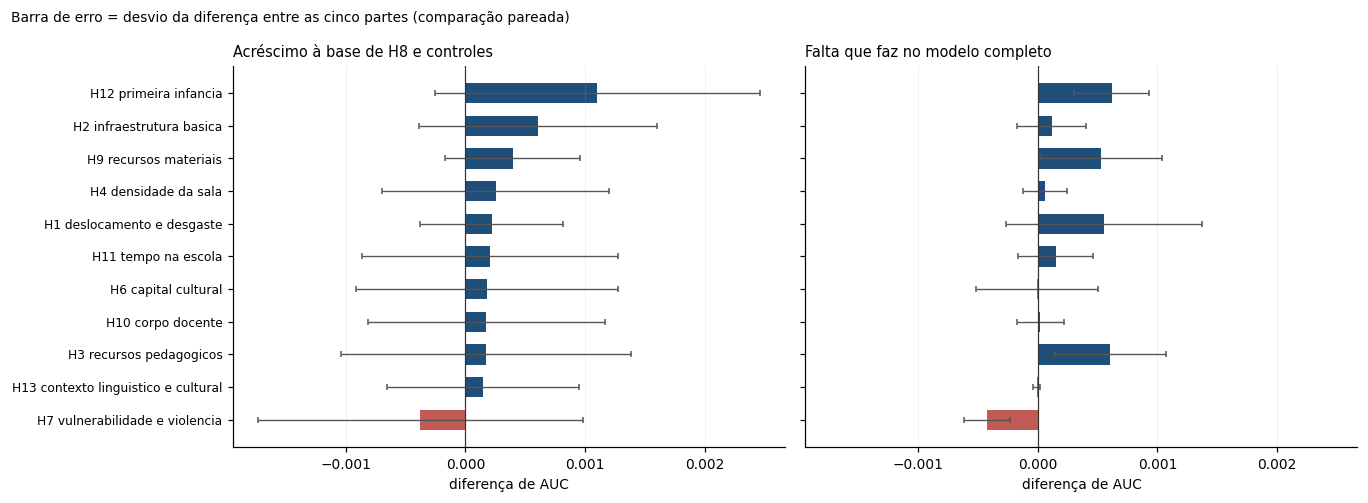

O MODELO EM TRÊS CONFIGURAÇÕES
                  variaveis     auc  auc_desvio  log_loss
configuracao                                             
H8 e controles           11  0.6628      0.0156    0.6326
todas                    43  0.6639      0.0145    0.6323
todas menos a H8         37  0.6476      0.0159    0.6411

Efeito de todas as hipóteses acionáveis somadas à base: +0.0011 de AUC (desvio entre as partes 0.0013)
Efeito de retirar a H8 do modelo completo: -0.0163 de AUC (desvio entre as partes 0.0038)

POR BLOCO DE HIPÓTESE
                                     variaveis  acrescimo_auc  acrescimo_desvio  falta_auc  falta_desvio  acrescimo_log_loss
H12 primeira infancia                      2.0         0.0011            0.0014     0.0006        0.0003              0.0004
H2 infraestrutura basica                   4.0         0.0006            0.0010     0.0001        0.0003              0.0001
H9 recursos materiais                      3.0         0.0004            0.0006     0.0

In [14]:
# --- 4.1 Acréscimo e falta de cada bloco de hipótese ---
from sklearn.ensemble import HistGradientBoostingClassifier

PARAMETROS_BLOCO = {"learning_rate": 0.05, "max_iter": 200,
                    "max_leaf_nodes": 15, "min_samples_leaf": 50}


def boosting_moderado():
    return HistGradientBoostingClassifier(random_state=SEMENTE, early_stopping=False,
                                          **PARAMETROS_BLOCO)


def codigo(v: str) -> str:
    """Código da hipótese: 'H8', 'H12', 'controle'."""
    return lista.loc[v, "hipotese"].split()[0]


BASE_H8 = [v for v in VARIAVEIS if codigo(v) in ("H8", "controle")]
BLOCOS = {}
for v in VARIAVEIS:
    if codigo(v) not in ("H8", "controle"):
        BLOCOS.setdefault(codigo(v), []).append(v)
BLOCOS = dict(sorted(BLOCOS.items(), key=lambda item: int(item[0][1:])))

configuracoes = {"H8 e controles": BASE_H8}
configuracoes.update({f"H8 e controles + {h}": BASE_H8 + vs for h, vs in BLOCOS.items()})
configuracoes["todas"] = VARIAVEIS
configuracoes.update({f"todas menos {h}": [v for v in VARIAVEIS if v not in vs]
                      for h, vs in BLOCOS.items()})
configuracoes["todas menos a H8"] = [v for v in VARIAVEIS if codigo(v) != "H8"]

inicio = time.time()
blocos = pd.DataFrame([
    {"configuracao": nome, "variaveis": len(vs),
     **validar(montar_modelo(boosting_moderado(), linear=False, variaveis=vs))}
    for nome, vs in configuracoes.items()]).set_index("configuracao")
print(f"{len(configuracoes)} configurações validadas em {time.time() - inicio:.0f} s")
print()

base, todas = blocos.loc["H8 e controles"], blocos.loc["todas"]
nome_hipotese = {lista.loc[v, "hipotese"].split()[0]: lista.loc[v, "hipotese"] for v in VARIAVEIS}


def diferenca(config_a: str, config_b: str) -> tuple:
    """Diferença de AUC entre duas configurações, parte a parte (comparação pareada)."""
    d = np.array(blocos.loc[config_a, "auc_dobras"]) - np.array(blocos.loc[config_b, "auc_dobras"])
    return float(d.mean()), float(d.std(ddof=1))


linhas = {}
for h, vs in BLOCOS.items():
    acrescimo, acrescimo_desvio = diferenca(f"H8 e controles + {h}", "H8 e controles")
    falta, falta_desvio = diferenca("todas", f"todas menos {h}")
    linhas[nome_hipotese[h]] = {
        "variaveis": len(vs),
        "acrescimo_auc": acrescimo, "acrescimo_desvio": acrescimo_desvio,
        "falta_auc": falta, "falta_desvio": falta_desvio,
        "acrescimo_log_loss": base["log_loss"] - blocos.loc[f"H8 e controles + {h}", "log_loss"]}
por_bloco = pd.DataFrame(linhas).T.sort_values("acrescimo_auc", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True, sharex=True)
ordem = por_bloco.iloc[::-1]
for eixo, coluna, titulo in [(ax1, "acrescimo", "Acréscimo à base de H8 e controles"),
                             (ax2, "falta", "Falta que faz no modelo completo")]:
    cores = np.where(ordem[f"{coluna}_auc"] > 0, "#1f4e79", "#c25b56")
    eixo.barh(ordem.index, ordem[f"{coluna}_auc"], xerr=ordem[f"{coluna}_desvio"],
              color=cores, height=.62, error_kw={"ecolor": "#555", "lw": .9, "capsize": 2})
    eixo.axvline(0, color="#333", lw=.8)
    eixo.set_title(titulo, fontsize=9.5, loc="left")
    eixo.set_xlabel("diferença de AUC")
    eixo.grid(axis="x", alpha=.22, lw=.6)
ax1.tick_params(axis="y", labelsize=8)
fig.suptitle("Barra de erro = desvio da diferença entre as cinco partes (comparação pareada)",
             fontsize=9, x=.01, ha="left")
plt.tight_layout()
plt.show()

print("O MODELO EM TRÊS CONFIGURAÇÕES")
print(blocos.loc[["H8 e controles", "todas", "todas menos a H8"],
                 ["variaveis", "auc", "auc_desvio", "log_loss"]].round(4).to_string())
print()
for rotulo, a, b in [("todas as hipóteses acionáveis somadas à base", "todas", "H8 e controles"),
                     ("retirar a H8 do modelo completo", "todas menos a H8", "todas")]:
    media, desvio = diferenca(a, b)
    print(f"Efeito de {rotulo}: {media:+.4f} de AUC (desvio entre as partes {desvio:.4f})")
print()
print("POR BLOCO DE HIPÓTESE")
print(por_bloco.round(4).to_string())

**Leitura.** O modelo só com o desempenho anterior e os controles, 11 variáveis, alcança AUC de 0,6628. Com as 43 variáveis, chega a 0,6639: somar todas as hipóteses acionáveis acrescenta 0,0011 de AUC, e o desvio desse acréscimo entre as partes é de 0,0013. O ganho não se distingue da oscilação da validação. Na direção oposta, retirar o desempenho anterior do modelo completo custa 0,0163 de AUC, com desvio de 0,0038: uma perda nítida.

Por bloco, nenhum acréscimo individual supera o próprio desvio. A primeira infância (H12) tem o maior acréscimo (0,0011) e é o único bloco cuja falta no modelo completo passa do dobro do desvio (0,0006 contra 0,0003). A vulnerabilidade e violência (H7) chega a piorar levemente o modelo (−0,0004), sinal de que acrescenta mais ruído que informação.

Isso não quer dizer que as variáveis acionáveis não carreguem informação. Sem o desempenho anterior, o modelo com elas alcança 0,6476, acima de repetir a taxa de 2023 (0,6414). O que acontece é que a informação delas já está contida no desempenho anterior: um município com melhores condições já tinha taxa mais alta em 2023, e a taxa daquele ano resume o efeito acumulado dessas condições. É o cenário previsto em `docs/hipoteses.md` para a H8, a hipótese contra a qual as outras competem, e ele é reportado aqui como achado.

📌 **Consequência para a modelagem e a interpretação.**

1. Para prever, o desempenho anterior faz quase todo o trabalho. As variáveis acionáveis ficam no modelo pelo ganho pequeno e pelo que permitem interpretar, e não por mudarem a qualidade da previsão.
2. Para responder quais fatores pesam na alfabetização, a importância das variáveis no modelo completo vai subestimar as acionáveis, porque a H8 absorve o efeito delas. A interpretabilidade da etapa seguinte deve ser lida em dois modelos: com a H8, para a previsão, e sem a H8, para os fatores.

## 5. Modelos candidatos e hiperparâmetros

**Passos desta seção:** (5.1) buscar os hiperparâmetros de três famílias de modelos; (5.2) comparar as combinações testadas.

Três famílias de modelos, escolhidas por representarem estratégias diferentes:

| Família | Como aprende | Hiperparâmetros buscados |
|---|---|---|
| regressão logística | um peso por variável, numa combinação linear | `C`, o inverso da força da regularização |
| gradient boosting | árvores em sequência, cada uma corrigindo o erro das anteriores | taxa de aprendizado, número de árvores, folhas por árvore, mínimo de linhas por folha, regularização |
| Random Forest | árvores independentes, treinadas em amostras diferentes, cuja média é a previsão | número de árvores, profundidade, mínimo de linhas por folha, fração de variáveis por divisão |

🎓 **Conceito, busca aleatória de hiperparâmetros.** Hiperparâmetros são as escolhas que o modelo não aprende sozinho, como a profundidade de uma árvore. Testar todas as combinações de uma grade seria caro; a busca aleatória sorteia um número fixo de combinações e mede cada uma pela mesma validação cruzada da seção 3. Com semente fixa, o sorteio é reprodutível. As combinações são avaliadas pela log-loss, que mede a qualidade da probabilidade, e todas ficam registradas em `reports/busca_hiperparametros.csv`.

📌 O gradient boosting usado é o do scikit-learn (`HistGradientBoostingClassifier`), que pertence à mesma família do XGBoost e dispensa dependência externa.

In [15]:
# --- 5.1 Busca aleatória de hiperparâmetros nas três famílias ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler

FAMILIAS = {
    "regressão logística": {
        "linear": True,
        "fabrica": lambda p: LogisticRegression(max_iter=3000, **p),
        "espaco": {"C": [float(c) for c in np.logspace(-3, 2, 10)]},
        "combinacoes": 10},
    "gradient boosting": {
        "linear": False,
        "fabrica": lambda p: HistGradientBoostingClassifier(
            random_state=SEMENTE, early_stopping=False, **p),
        "espaco": {"learning_rate": [0.02, 0.05, 0.1, 0.2],
                   "max_iter": [100, 200, 400],
                   "max_leaf_nodes": [7, 15, 31, 63],
                   "min_samples_leaf": [10, 20, 50, 100, 200],
                   "l2_regularization": [0.0, 0.1, 1.0, 10.0]},
        "combinacoes": 20},
    "random forest": {
        "linear": False,
        "fabrica": lambda p: RandomForestClassifier(
            random_state=SEMENTE, n_jobs=-1, **p),
        "espaco": {"n_estimators": [200, 400],
                   "max_depth": [None, 8, 12, 20],
                   "min_samples_leaf": [2, 5, 10, 20, 50],
                   "max_features": ["sqrt", 0.3, 0.5]},
        "combinacoes": 12},
}

linhas = []
for familia, f in FAMILIAS.items():
    inicio = time.time()
    for parametros in ParameterSampler(f["espaco"], n_iter=f["combinacoes"],
                                       random_state=SEMENTE):
        medidas = validar(montar_modelo(f["fabrica"](parametros), f["linear"]))
        linhas.append({"familia": familia, "parametros": parametros, **medidas})
    print(f"{familia:<22} {f['combinacoes']:>3} combinações em {time.time() - inicio:.0f} s")

busca = pd.DataFrame(linhas)
busca.assign(parametros=busca["parametros"].map(json.dumps)).to_csv(
    "../reports/busca_hiperparametros.csv", index=False, encoding="utf-8")
print(f"\n{len(busca)} combinações registradas em reports/busca_hiperparametros.csv")

regressão logística     10 combinações em 11 s


gradient boosting       20 combinações em 770 s


random forest           12 combinações em 94 s

42 combinações registradas em reports/busca_hiperparametros.csv


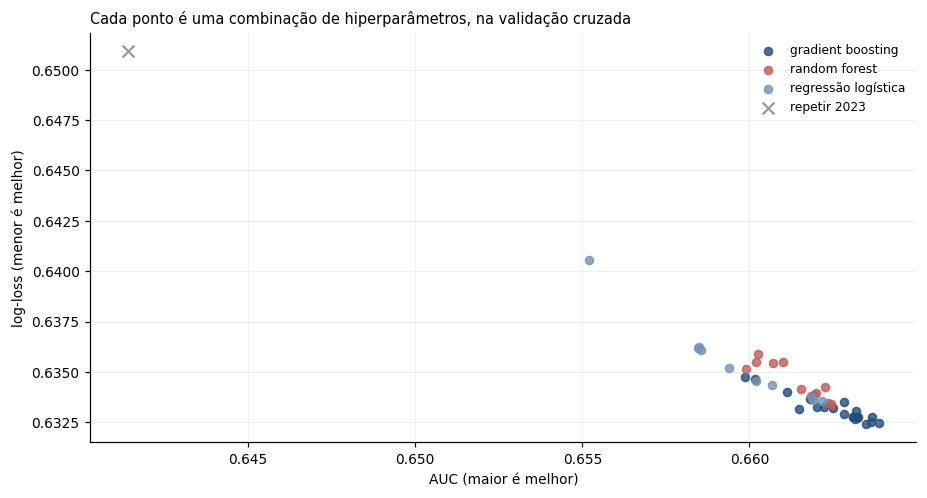

A MELHOR COMBINAÇÃO DE CADA FAMÍLIA, PELA LOG-LOSS
                        auc  auc_desvio  log_loss  log_loss_desvio   brier
familia                                                                   
gradient boosting    0.6635      0.0143    0.6324           0.0086  0.2217
random forest        0.6624      0.0145    0.6334           0.0086  0.2221
regressão logística  0.6622      0.0160    0.6335           0.0089  0.2220

  gradient boosting      {'min_samples_leaf': 20, 'max_leaf_nodes': 15, 'max_iter': 200, 'learning_rate': 0.05, 'l2_regularization': 0.0}
  random forest          {'n_estimators': 400, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 8}
  regressão logística    {'C': 0.1668100537200059}

Amplitude da log-loss entre as combinações de cada família:
                        min     max
familia                            
gradient boosting    0.6324  0.6348
random forest        0.6334  0.6359
regressão logística  0.6335  0.6406


In [16]:
# --- 5.2 Comparar as combinações testadas ---
cores_familia = {"regressão logística": "#6f94b8", "gradient boosting": "#1f4e79",
                 "random forest": "#c25b56"}
fig, eixo = plt.subplots(figsize=(8.5, 4.6))
for familia, d in busca.groupby("familia"):
    eixo.scatter(d["auc"], d["log_loss"], s=28, alpha=.8,
                 color=cores_familia[familia], label=familia)
for nome, cor in [("repetir 2023", "#9a9a9a")]:
    eixo.scatter(referencias.loc[nome, "auc"], referencias.loc[nome, "log_loss"],
                 marker="x", s=60, color=cor, label=nome)
eixo.set_xlabel("AUC (maior é melhor)")
eixo.set_ylabel("log-loss (menor é melhor)")
eixo.set_title("Cada ponto é uma combinação de hiperparâmetros, na validação cruzada",
               fontsize=9.5, loc="left")
eixo.legend(fontsize=8, frameon=False)
eixo.grid(alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

melhores = (busca.loc[busca.groupby("familia")["log_loss"].idxmin()]
            .set_index("familia")
            .sort_values("log_loss"))
print("A MELHOR COMBINAÇÃO DE CADA FAMÍLIA, PELA LOG-LOSS")
print("=" * 100)
print(melhores[["auc", "auc_desvio", "log_loss", "log_loss_desvio", "brier"]].round(4).to_string())
print()
for familia, linha in melhores.iterrows():
    print(f"  {familia:<22} {linha['parametros']}")
print()
print("Amplitude da log-loss entre as combinações de cada família:")
print(busca.groupby("familia")["log_loss"].agg(["min", "max"]).round(4).to_string())

**Leitura.** As 42 combinações testadas ficam muito próximas. A melhor de cada família tem log-loss entre 0,6324 e 0,6335 e AUC entre 0,6622 e 0,6635: a distância entre as famílias, de 0,0011 de log-loss, é quase dez vezes menor que a oscilação da própria validação entre as partes, de cerca de 0,009. O melhor resultado, do gradient boosting, alcança 89% do caminho entre a constante e a AUC máxima possível, um ponto acima da regressão logística com os valores padrão.

Dentro de cada família, os hiperparâmetros também mudam pouco, e a direção é a mesma nas três: as combinações mais contidas vencem.

- **Gradient boosting:** as melhores usam taxa de aprendizado de 0,05 e até 15 folhas por árvore; as piores combinam taxa de 0,2 com 63 folhas, as mais flexíveis da busca.
- **Random Forest:** a melhor limita a profundidade a 8 níveis e exige 10 linhas por folha.
- **Regressão logística:** a regularização um pouco mais forte que a padrão (C de 0,167, contra 1) melhora pouco a log-loss; a regularização muito forte (C de 0,001) piora.

É o que se espera de uma base com cerca de 3.900 combinações distintas de município e rede (seção 1.3): um modelo flexível demais passa a decorar essas combinações e erra nos municípios que não viu.

📌 **Consequência para a escolha.** Com estas variáveis, a família do modelo não muda a qualidade da previsão. A escolha entre elas não pode se apoiar em uma diferença que a validação não distingue, e por isso segue o critério declarado na seção 6, que favorece o modelo mais simples dentro dessa margem.

## 6. Comparação na validação

**Passos desta seção:** (6.1) escolher o modelo pelo critério declarado; (6.2) medir os finalistas na partição de validação; (6.3) conferir a ordenação e a calibração; (6.4) comparar a taxa prevista com a real, por município; (6.5) registrar o modelo escolhido.

**O critério de escolha, declarado antes de ver a validação:** vence a família com a menor log-loss na validação cruzada. Se a regressão logística ficar a menos de um desvio da vencedora, isto é, dentro da oscilação da própria validação, ela é a escolhida, por ser mais simples e interpretável. A partição de validação, que nenhum modelo viu até aqui, confirma ou contesta a escolha. A partição de teste continua fechada, para a avaliação final do desenv_04.

In [17]:
# --- 6.1 Escolha pelo critério declarado ---
vencedora = melhores["log_loss"].idxmin()
distancia_logistica = (melhores.loc["regressão logística", "log_loss"]
                       - melhores.loc[vencedora, "log_loss"])
tolerancia = melhores.loc[vencedora, "log_loss_desvio"]
escolhida = ("regressão logística" if distancia_logistica <= tolerancia else vencedora)

print(f"Menor log-loss na validação cruzada: {vencedora} "
      f"({melhores.loc[vencedora, 'log_loss']:.4f}, desvio {tolerancia:.4f})")
print(f"Distância da regressão logística até ela: {distancia_logistica:.4f}")
print(f"Família escolhida pelo critério: {escolhida}")

Menor log-loss na validação cruzada: gradient boosting (0.6324, desvio 0.0086)
Distância da regressão logística até ela: 0.0011
Família escolhida pelo critério: regressão logística


In [18]:
# --- 6.2 Os finalistas na partição de validação ---
def treinar_final(familia: str, parametros: dict) -> Pipeline:
    """Treina a combinação escolhida no treino inteiro, com os pesos normalizados."""
    f = FAMILIAS[familia]
    modelo = montar_modelo(f["fabrica"](parametros), f["linear"])
    return modelo.fit(X_treino, y_treino,
                      modelo__sample_weight=(w_treino / w_treino.mean()).to_numpy())


finais = {familia: treinar_final(familia, linha["parametros"])
          for familia, linha in melhores.iterrows()}
prob_validacao = {familia: m.predict_proba(X_validacao)[:, 1] for familia, m in finais.items()}

# as referências, calculadas da mesma forma na validação
taxa_treino = np.average(y_treino, weights=w_treino)
prob_validacao["repetir 2023"] = (X_validacao["rede_taxa_ant"] / 100).fillna(taxa_treino).to_numpy()
d = pd.DataFrame({"municipio": municipio_validacao.to_numpy(),
                  "rede": X_validacao["rede_nome"].to_numpy(),
                  "sim": (y_validacao * w_validacao).to_numpy(), "alunos": w_validacao.to_numpy()})
grupo = d.groupby(["municipio", "rede"])
prob_melhor_validacao = (grupo["sim"].transform("sum") / grupo["alunos"].transform("sum")).to_numpy()

validacao = pd.DataFrame({nome: medir(y_validacao, p, w_validacao)
                          for nome, p in {**prob_validacao, "melhor previsão possível": prob_melhor_validacao}.items()}).T
validacao["pct_do_caminho"] = (100 * (validacao["auc"] - 0.5)
                               / (validacao.loc["melhor previsão possível", "auc"] - 0.5)).round(0)
validacao = validacao.sort_values("log_loss")
print("PARTIÇÃO DE VALIDAÇÃO (municípios que nenhum modelo viu)")
print("=" * 70)
print(validacao.round(4).to_string())
print()
ordem_cv = list(melhores.index)
ordem_val = [f for f in validacao.index if f in FAMILIAS]
print(f"Ordem das famílias pela log-loss: validação cruzada {ordem_cv}")
print(f"                                   validação         {ordem_val}")
print(f"A validação {'confirma' if ordem_val[0] == ordem_cv[0] else 'não confirma'} "
      f"a família de menor log-loss na validação cruzada.")

PARTIÇÃO DE VALIDAÇÃO (municípios que nenhum modelo viu)
                        auc  log_loss   brier  pct_do_caminho
teto                 0.6710    0.6247  0.2184           100.0
gradient boosting    0.6451    0.6381  0.2241            85.0
random forest        0.6440    0.6387  0.2243            84.0
regressão logística  0.6444    0.6395  0.2247            84.0
repetir 2023         0.6305    0.6528  0.2293            76.0

Ordem das famílias pela log-loss: validação cruzada ['gradient boosting', 'random forest', 'regressão logística']
                                   validação         ['gradient boosting', 'random forest', 'regressão logística']
A validação confirma a família de menor log-loss na validação cruzada.


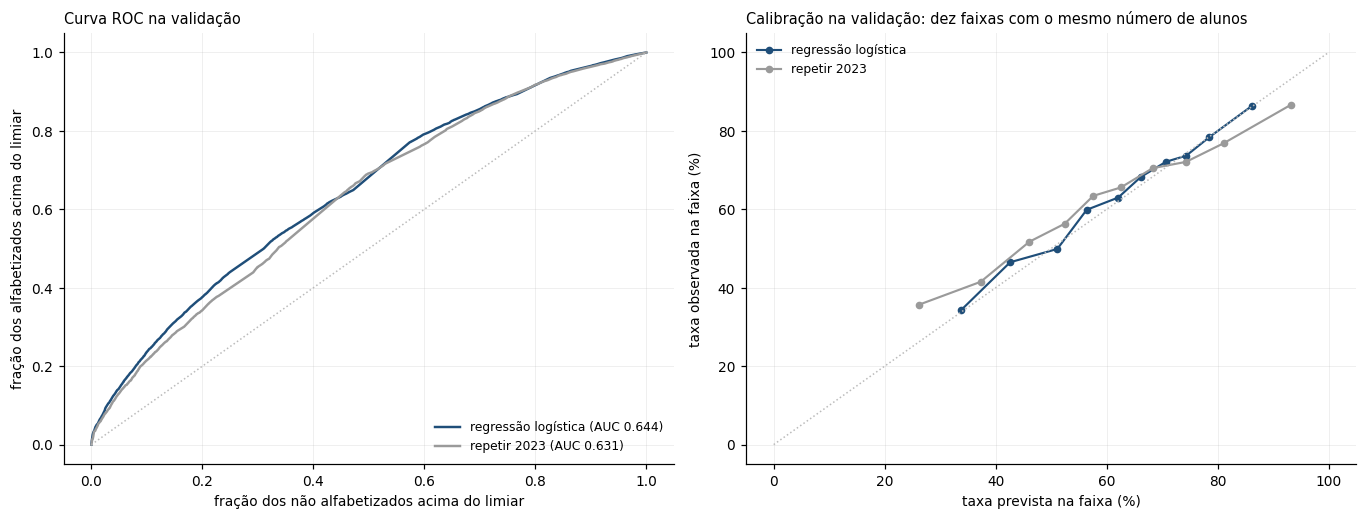

Calibração de regressão logística: maior distância entre prevista e observada numa faixa, 3.9 pontos percentuais


In [19]:
# --- 6.3 Ordenação e calibração na validação ---
from sklearn.metrics import roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))
curvas = {escolhida: "#1f4e79", "repetir 2023": "#9a9a9a"}
for nome, cor in curvas.items():
    fp, vp, _ = roc_curve(y_validacao, prob_validacao[nome], sample_weight=w_validacao)
    ax1.plot(fp, vp, color=cor, lw=1.6,
             label=f"{nome} (AUC {validacao.loc[nome, 'auc']:.3f})")
ax1.plot([0, 1], [0, 1], color="#bbb", ls=":", lw=1)
ax1.set_xlabel("fração dos não alfabetizados acima do limiar")
ax1.set_ylabel("fração dos alfabetizados acima do limiar")
ax1.set_title("Curva ROC na validação", fontsize=9.5, loc="left")
ax1.legend(fontsize=8, frameon=False, loc="lower right")

# calibração: dez faixas de probabilidade prevista, ponderadas pelos alunos
calibracao = {}
for nome, cor in curvas.items():
    c = pd.DataFrame({"p": prob_validacao[nome], "y": y_validacao.to_numpy(),
                      "w": w_validacao.to_numpy()}).sort_values("p")
    c["faixa"] = pd.qcut(c["w"].cumsum(), 10, labels=False)
    g = c.groupby("faixa").apply(lambda x: pd.Series({
        "prevista": np.average(x["p"], weights=x["w"]),
        "observada": np.average(x["y"], weights=x["w"])}))
    calibracao[nome] = g
    ax2.plot(100 * g["prevista"], 100 * g["observada"], "o-", color=cor, lw=1.4, ms=4,
             label=nome)
ax2.plot([0, 100], [0, 100], color="#bbb", ls=":", lw=1)
ax2.set_xlabel("taxa prevista na faixa (%)")
ax2.set_ylabel("taxa observada na faixa (%)")
ax2.set_title("Calibração na validação: dez faixas com o mesmo número de alunos",
              fontsize=9.5, loc="left")
ax2.legend(fontsize=8, frameon=False, loc="upper left")
for eixo in (ax1, ax2):
    eixo.grid(alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

g = calibracao[escolhida]
print(f"Calibração de {escolhida}: maior distância entre prevista e observada "
      f"numa faixa, {100 * (g['prevista'] - g['observada']).abs().max():.1f} pontos percentuais")

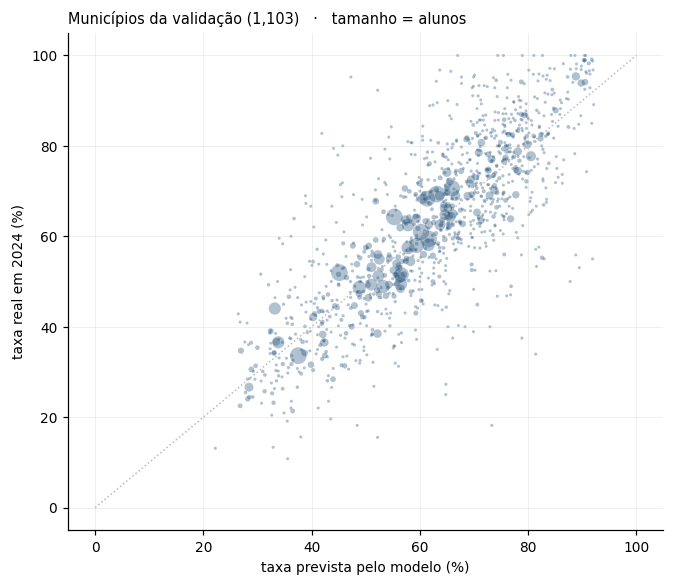

TAXA POR MUNICÍPIO NA VALIDAÇÃO
  regressão logística    erro absoluto mediano   6.9 pp   correlação 0.788
  repetir 2023           erro absoluto mediano   9.0 pp   correlação 0.637


In [20]:
# --- 6.4 Taxa prevista e taxa real, por município ---
# A soma das probabilidades dos alunos de um município é a taxa prevista para
# ele; é por aí que o modelo responde às perguntas de negócio da etapa 7.
por_municipio = {}
for nome in [escolhida, "repetir 2023"]:
    d = pd.DataFrame({"municipio": municipio_validacao.to_numpy(), "w": w_validacao.to_numpy(),
                      "p": prob_validacao[nome] * w_validacao.to_numpy(),
                      "y": (y_validacao * w_validacao).to_numpy()})
    g = d.groupby("municipio")[["w", "p", "y"]].sum()
    g["prevista"], g["real"] = 100 * g["p"] / g["w"], 100 * g["y"] / g["w"]
    por_municipio[nome] = g

g = por_municipio[escolhida]
fig, eixo = plt.subplots(figsize=(6.2, 5.4))
eixo.scatter(g["prevista"], g["real"], s=np.clip(g["w"] / 40, 4, 120), alpha=.35,
             color="#1f4e79", edgecolor="none")
eixo.plot([0, 100], [0, 100], color="#bbb", ls=":", lw=1)
eixo.set_xlabel("taxa prevista pelo modelo (%)")
eixo.set_ylabel("taxa real em 2024 (%)")
eixo.set_title(f"Municípios da validação ({len(g):,})   ·   tamanho = alunos",
               fontsize=9.5, loc="left")
eixo.grid(alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

print("TAXA POR MUNICÍPIO NA VALIDAÇÃO")
print("=" * 72)
for nome, g in por_municipio.items():
    erro = (g["prevista"] - g["real"]).abs()
    print(f"  {nome:<22} erro absoluto mediano {erro.median():5.1f} pp   "
          f"correlação {g['prevista'].corr(g['real']):.3f}")

In [21]:
# --- 6.5 Registrar o modelo escolhido ---
registro = {
    "familia": escolhida,
    "parametros": melhores.loc[escolhida, "parametros"],
    "criterio": "menor log-loss na validação cruzada; a regressão logística vence "
                "se ficar a menos de um desvio da melhor",
    "validacao_cruzada": {k: round(float(melhores.loc[escolhida, k]), 5)
                          for k in ["auc", "auc_desvio", "log_loss", "log_loss_desvio", "brier"]},
    "validacao": {k: round(float(validacao.loc[escolhida, k]), 5)
                  for k in ["auc", "log_loss", "brier"]},
    "semente": SEMENTE,
    "variaveis": VARIAVEIS,
}
Path("../reports/modelo_escolhido.json").write_text(
    json.dumps(registro, ensure_ascii=False, indent=2), encoding="utf-8")

comparacao = pd.concat({"validacao_cruzada": referencias[["auc", "log_loss", "brier"]]
                        .combine_first(melhores[["auc", "log_loss", "brier"]]),
                        "validacao": validacao[["auc", "log_loss", "brier"]]}, axis=1)
comparacao.round(5).to_csv("../reports/comparacao_modelos.csv", encoding="utf-8")

print("Registrado em reports/modelo_escolhido.json e reports/comparacao_modelos.csv")
print(json.dumps({k: registro[k] for k in ["familia", "parametros", "validacao_cruzada",
                                          "validacao"]}, ensure_ascii=False, indent=2))

Registrado em reports/modelo_escolhido.json e reports/comparacao_modelos.csv
{
  "familia": "regressão logística",
  "parametros": {
    "C": 0.1668100537200059
  },
  "validacao_cruzada": {
    "auc": 0.66217,
    "auc_desvio": 0.01596,
    "log_loss": 0.63355,
    "log_loss_desvio": 0.00889,
    "brier": 0.22205
  },
  "validacao": {
    "auc": 0.64437,
    "log_loss": 0.63954,
    "brier": 0.22466
  }
}


**Leitura.** Pelo critério declarado, a escolhida é a regressão logística, com C de 0,167. O gradient boosting teve a menor log-loss na validação cruzada (0,6324), mas a logística ficou a 0,0011 dele, bem dentro do desvio de 0,0086.

Na partição de validação, com municípios que nenhum modelo viu, as três famílias mantêm a ordem da validação cruzada e continuam praticamente empatadas, com AUC entre 0,6440 e 0,6451 e log-loss entre 0,6381 e 0,6395. A logística alcança 84% do caminho entre a constante e a AUC máxima possível, contra 76% de repetir a taxa de 2023. Os valores ficam abaixo dos da validação cruzada (AUC de 0,644, contra 0,662), mas a AUC máxima possível também cai (0,671, contra 0,683): a partição de validação reúne municípios um pouco mais difíceis de ordenar, e a queda do modelo acompanha a do limite possível.

**As probabilidades são confiáveis.** Nas dez faixas com o mesmo número de alunos, a maior distância entre a taxa prevista pela logística e a observada é de 3,9 pontos percentuais. Repetir a taxa de 2023 erra nas pontas: subestima as redes que iam mal e superestima as que iam bem, porque os resultados regridem à média de um ano para o outro (seção 4.2 do desenv_02). A logística corrige esse exagero.

**No município, o ganho é maior.** Somando as probabilidades dos alunos, a taxa prevista para cada município da validação erra por 6,9 pontos na mediana, contra 9,0 de repetir a taxa de 2023, e a correlação com a taxa real sobe de 0,637 para 0,788.

📌 **Consequência para as próximas etapas.**

1. O modelo escolhido está registrado em `reports/modelo_escolhido.json`, com os hiperparâmetros e as medidas, e a comparação completa em `reports/comparacao_modelos.csv`. A avaliação final, na partição de teste, e a interpretabilidade ficam para o desenv_04.
2. A previsão é mais útil no nível do município do que no do aluno: é aí que o modelo supera com mais folga a regra de repetir o ano anterior, e é esse o nível das perguntas de negócio sobre municípios em risco e metas.

---

## Parecer final: o que o modelo entrega e como ele será usado

**O que o enunciado pede:** um modelo supervisionado que preveja se um aluno será alfabetizado.

**O que foi construído:** três famílias de modelos que fazem exatamente isso, comparadas em 42 combinações de hiperparâmetros: regressão logística, gradient boosting e Random Forest. Todas recebem cada aluno e devolvem a probabilidade de ele ser alfabetizado, com o mesmo pré-processamento integrado ao pipeline, o mesmo tratamento de vazamento e a mesma validação agrupada por município. Entre elas, a regressão logística foi a escolhida, pelo critério declarado na seção 6: as três empataram dentro da oscilação da validação, e o critério favorece a mais simples.

**O que a performance mostra:**

- **A AUC é modesta, e o limite está nos dados.** Na validação, a logística alcança AUC de 0,644, contra a AUC máxima possível de 0,671, a da melhor previsão possível com estas variáveis (6.2). Ela é baixa porque os dados públicos não trazem atributos do aluno: todas as variáveis são iguais para os alunos da mesma rede no mesmo município, e é entre esses alunos que está 90% da diferença de resultado (seção 8.1 do desenv_02).
- **A família do modelo não muda o resultado.** Regressão logística, gradient boosting e Random Forest empatam dentro da oscilação da validação (5.2).
- **O desempenho anterior faz quase todo o trabalho.** As hipóteses acionáveis acrescentam 0,0011 de AUC a ele, dentro da oscilação; retirá-lo custa 0,016 (4.1).
- **No nível da rede em cada município, o modelo funciona bem.** Somando as probabilidades dos alunos, a taxa prevista de cada município erra por 6,9 pontos na mediana, contra 9,0 de repetir a taxa do ano anterior, e a correlação com a taxa real é de 0,79 (6.4).

**Parecer.** O modelo cumpre o enunciado no plano técnico, mas a previsão aluno a aluno tem valor limitado: dois alunos da mesma rede, no mesmo município, recebem a mesma probabilidade. O valor do modelo está na previsão agregada por rede e município. Isso se distancia da expectativa literal do enunciado, que é distinguir alunos, e fica declarado como a principal limitação do projeto. Não é uma escolha de modelagem, e sim o limite da informação disponível; ele só seria superado com dados no grão do aluno ou da escola, que os microdados públicos não oferecem.

**A abordagem daqui em diante.** O modelo continua sendo de aluno, mas passa a ser **usado e avaliado no nível da rede em cada município**:

1. cada rede, estadual ou municipal, recebe a taxa prevista pelo modelo;
2. a taxa prevista é comparada com a meta nacional pactuada para 2024, de 59,9%, que funciona como régua comum a todas as redes; a meta pactuada do próprio município entra como leitura complementar da rede municipal;
3. a avaliação final mede, na partição de teste, se o modelo aponta como abaixo da meta as mesmas redes que de fato ficaram abaixo: das redes marcadas em risco, quantas ficaram abaixo (precisão), e das que ficaram abaixo, quantas foram marcadas (sensibilidade);
4. a interpretabilidade é lida em dois modelos, com e sem o desempenho anterior, porque no modelo completo ele absorve o efeito dos fatores acionáveis (4.1).

**Como essa abordagem responde às perguntas do enunciado:**

| Pergunta do enunciado | Como é respondida |
|---|---|
| Quais municípios estão em maior risco | as redes com taxa prevista mais distante da meta, com o número de alunos envolvidos |
| Previsão de quem não atingirá as metas | a classificação de cada rede diante da meta de 2024, com precisão e sensibilidade medidas no teste |
| Quais fatores mais impactam a alfabetização | a interpretabilidade do modelo sem o desempenho anterior, lida junto com as hipóteses do desenv_02 |
| Quais variáveis são mais influentes | a interpretabilidade do modelo completo, em que o desempenho anterior lidera |
| Regiões com padrões semelhantes | o agrupamento das redes pelas suas características, na aplicação estratégica |

A avaliação final, a interpretabilidade e a comparação com a meta ficam para o desenv_04.